# Q8. Which missense predictors are practical baselines, and how does AlphaMissense perform on the pilot?

**Reviewed 2026-09-07.** This survey covers six missense-specific tools. **AlphaMissense is the selected reference predictor; ClinVar remains the ground truth.** The benchmark uses Q1's frozen 5,000 missense SNVs, with 3,658 training and 1,342 validation variants.

[Survey code](src/q8.py) · [Source catalog](src/q8_catalog.json) · [Benchmark code](src/q8_baseline.py) · [Dependencies](../requirements.txt).

Run [Q1](Q1-clinvar-split.ipynb) first to reproduce the fixed inputs. Then run this notebook from a fresh **Gamow** kernel in cell order. CPU only; no model weights or GPU required. The first run downloads approximately **643 MB** into `data/alphamissense/`; later runs verify and reuse the archive, with no network required. Lookup streams the compressed release, keeping only pilot matches in memory. The earlier broad survey is preserved in `results/archive/q8_before_missense_baseline/`.

In [1]:
from src import q8, q8_baseline
survey = q8.load_survey()

6 representative tools · reviewed 2026-09-07 · CPU only · offline
The catalog is bundled offline; the later AlphaMissense benchmark acquires external scores.


## Missense tools

The diagram summarizes methods, not performance. Expand the comparison for access, compute, licenses, training sources and clinical calibration exposure.

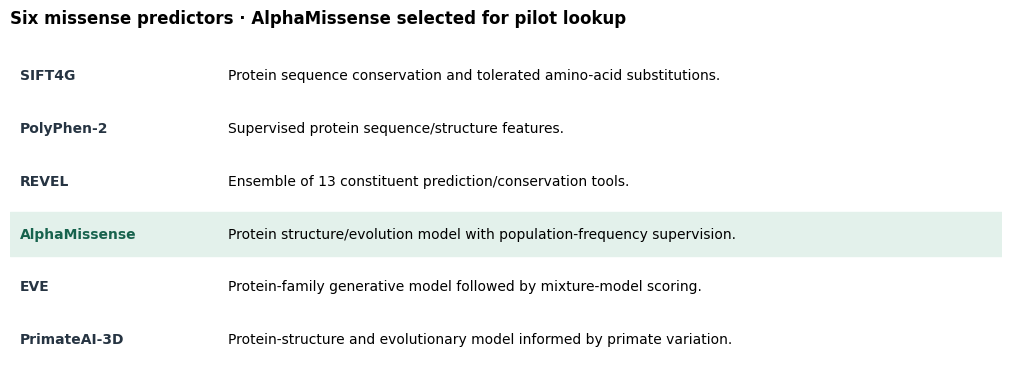

Tool,Release,Method,Variants,Inputs,Access,Compute,License,Sources
SIFT4G,2016 method; reviewed source revision pinned,Protein sequence conservation and tolerated amino-acid substitutions.,Missense substitutions; transcript/protein mapping is required for genomic SNVs.,Protein FASTA queries and a homologous protein sequence database.,Public local implementation; annotation databases must match the selected species and reference.,CPU supported; optional CUDA acceleration for database construction/scoring.,Implementation: GPL-3.0; external sequence database terms are separate.,"SIFT4G — source, protein inputs and compute · SIFT4G — GPL-3.0 license · Vaser et al. — SIFT missense predictions for genomes (2016)"
PolyPhen-2,2.2.3r408; choose HumDiv or HumVar explicitly,Supervised protein sequence/structure features.,Missense substitutions in supported proteins.,"Protein accession, residue position and amino-acid substitution; genomic mapping is also available.","Web interface, standalone software and precomputed annotations.",CPU lookup or local scoring with protein/structure databases.,Academic instruction/research use; other use requires the authors' commercial license.,PolyPhen-2 — release 2.2.3r408 and usage terms · PolyPhen-2 — HumDiv and HumVar training data · Adzhubei et al. — PolyPhen-2 protocol (2013)
REVEL,2016 model; official score export updated 2021-05-03,Ensemble of 13 constituent prediction/conservation tools.,Missense SNVs with valid protein/transcript mappings.,Genomic alleles plus transcript/amino-acid mapping; some lifted GRCh38 positions are missing.,Downloadable precomputed score files.,CPU lookup; relatively little work after downloading and indexing scores.,Scores: non-commercial use; contact authors for other uses.,"REVEL — method and training overview · REVEL — 2021 score export, GRCh38 mapping and terms"
AlphaMissense,2023 prediction release; code reference pinned,Protein structure/evolution model with population-frequency supervision.,Human missense substitutions in the released transcript/protein catalog.,Exact GRCh38 alleles for this benchmark; retain transcript/protein annotations from the published score file.,Public precomputed predictions and reference code; trained weights are not provided.,CPU lookup of the score release; new inference cannot be reproduced from the published code alone.,Code: Apache-2.0. Later official README: predictions CC BY 4.0; pinned 2023 archive header: CC BY-NC-SA 4.0. Both statements are retained in provenance.,"AlphaMissense — score availability, missing weights and licenses · DeepMind — AlphaMissense training and predictions · Cheng et al. — AlphaMissense (2023) · EMBL-EBI — AlphaMissense score calibration and thresholds · DeepMind AlphaMissense — pinned hg38 score archive metadata"
EVE,2021 method; reviewed source revision pinned,Protein-family generative model followed by mixture-model scoring.,Missense substitutions for proteins and positions covered by the released models.,Protein/residue mapping for lookup; a protein-family MSA for new model fitting.,Public score browser/downloads and code for rebuilding models.,CPU lookup; fitting new protein-family models requires MSA preparation and substantial compute.,Code: MIT; confirm the terms of any separately downloaded dataset.,"EVE — MSA training, score downloads, ClinVar evaluation and MIT license"
PrimateAI-3D,2023 method; reviewed PyTorch source revision pinned,Protein-structure and evolutionary model informed by primate variation.,Human missense substitutions.,Score lookup by genomic/protein mapping; local models use structure and evolutionary features.,Browser and downloadable scores after an academic license agreement; source repository available.,CPU score lookup; new predictions require the model and structure/sequence resources.,Scores: academic non-profit research agreement; commercial scores/models require separate licensing.,"PrimateAI-3D — score access, academic agreement and PyTorch implementation · Illumin

Tool,Training,Clinvar,Caution,Sources
SIFT4G,Evolutionary protein sequence alignments; no clinical-label fitting in the core scoring method.,This review does not establish independence of every distributed database or later benchmark.,A protein-impact score is not a calibrated disease probability; missing mappings and alignments limit applicability.,"SIFT4G — source, protein inputs and compute · SIFT4G — GPL-3.0 license · Vaser et al. — SIFT missense predictions for genomes (2016)"
PolyPhen-2,HumDiv/HumVar include known disease/function variants and neutral comparators.,Disease variants can recur in ClinVar even though the original training sources were different.,"Audit the exact model and training overlap; useful as a historical comparator, not an assumed independent reference.",PolyPhen-2 — release 2.2.3r408 and usage terms · PolyPhen-2 — HumDiv and HumVar training data · Adzhubei et al. — PolyPhen-2 protocol (2013)
REVEL,HGMD disease variants and rare neutral variants; constituents bring their own training histories.,ClinVar was a published evaluation set; overlapping variants and inherited labels remain concerns.,Use only with an explicit overlap audit and report mapping failures rather than treating absent scores as benign.,"REVEL — method and training overview · REVEL — 2021 score export, GRCh38 mapping and terms"
AlphaMissense,Human/primate population-frequency labels; core model is not fitted directly to ClinVar classifications.,Released scores are calibrated and category thresholds selected using ClinVar; clinical benchmarking is also reported.,Use continuous scores and audit calibration membership; do not describe this as wholly ClinVar-independent.,"AlphaMissense — score availability, missing weights and licenses · DeepMind — AlphaMissense training and predictions · Cheng et al. — AlphaMissense (2023) · EMBL-EBI — AlphaMissense score calibration and thresholds · DeepMind AlphaMissense — pinned hg38 score archive metadata"
EVE,Evolutionary MSAs; the core workflow requires no clinical labels.,"ClinVar labels are supplied for evaluation, separate from MSA model fitting.",Coverage and homologous-sequence exposure still matter; external clinical calibration would need a separate audit.,"EVE — MSA training, score downloads, ClinVar evaluation and MIT license"
PrimateAI-3D,Common human/primate variation with structural and evolutionary learning objectives.,The authors report clinical benchmarking without relying on clinical annotations for core training.,Exact population and protein overlap are not audited here; availability is gated by the score agreement.,"PrimateAI-3D — score access, academic agreement and PyTorch implementation · Illumina research team — PrimateAI-3D training and scope"


In [2]:
q8.show_landscape(survey)
q8.show_comparison(survey)

## Selected reference: AlphaMissense

The [official release](https://github.com/google-deepmind/alphamissense/blob/fe2dc845f93310abd6c1b0e8955d7a96c2144d66/README.md) supplies precomputed human missense scores; trained weights are unavailable. Direct GRCh38 lookup avoids additional protein annotation infrastructure. Selection reflects practical access, not a claim that AlphaMissense outperforms the other surveyed tools.

The released scores and classification thresholds use ClinVar calibration ([calibration explanation](https://www.ebi.ac.uk/training/online/courses/alphafold/classifying-the-effects-of-missense-variants-using-alphamissense/understanding-pathogenicity-scores-from-alphamissense/)). Exact calibration membership is unresolved, so these scores cannot serve as independent biological ground truth. We use continuous scores and retain the original ClinVar outcomes. The archive header says CC BY-NC-SA 4.0 while the later official README says CC BY 4.0; provenance records both statements.

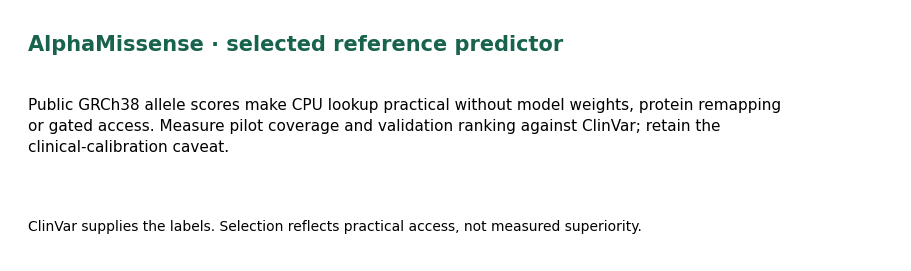

Survey checks passed; catalog, comparisons, figures and provenance saved to results/q8/.


In [3]:
q8.show_shortlist(survey)
q8.export_results(survey)

## Reproducible setup and pilot evaluation

The following call verifies Q1 file checksums and reruns its full-cohort, missense and sequence leakage audits. It freezes the lookup/evaluation settings before reading outcomes, downloads the pinned AlphaMissense hg38 generation when absent, and verifies the archive's published MD5. Partial or corrupt downloads fail before use.

**Matching:** exact GRCh38 chromosome, 1-based position, REF and ALT, removing only the `chr` prefix. No liftover or reverse complementation. For multiple matching transcript annotations, use the **maximum continuous score**, fixed independently of labels. Save every matched annotation, transcript count, minimum score and score range. Unmatched alleles remain unscored.

**Evaluation:** score both partitions; load ClinVar outcomes only after lookup. Report coverage by split and class, then validation AUROC and average precision on covered variants. Percentile 95% intervals use 1,000 bootstrap samples of Q1 components with seed 42; all members are resampled together before restricting to covered variants. One-class replicates are skipped and counted. No threshold tuning, recalibration or Q2 retraining occurs.

`clinvar-test-pilot.vcf` is **validation**, not an independent test. Q1 checks certify the local split, not independence from AlphaMissense's external protein/evolutionary inputs or clinical calibration.

Reusing verified AlphaMissense archive.


  Read 20,000,000 score rows; retained 1,327 annotations.


  Read 40,000,000 score rows; retained 2,677 annotations.


  Read 60,000,000 score rows; retained 3,922 annotations.


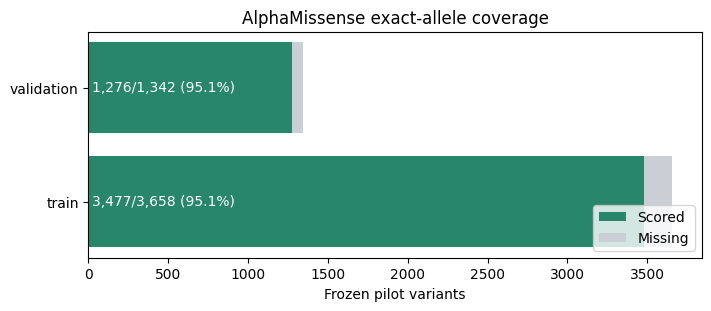

split,class,total,covered,missing,coverage_fraction
train,all,3658,3477,181,0.950519
train,benign,2213,2088,125,0.943516
train,pathogenic,1445,1389,56,0.961246
validation,all,1342,1276,66,0.950820
validation,benign,867,829,38,0.956171
validation,pathogenic,475,447,28,0.941053


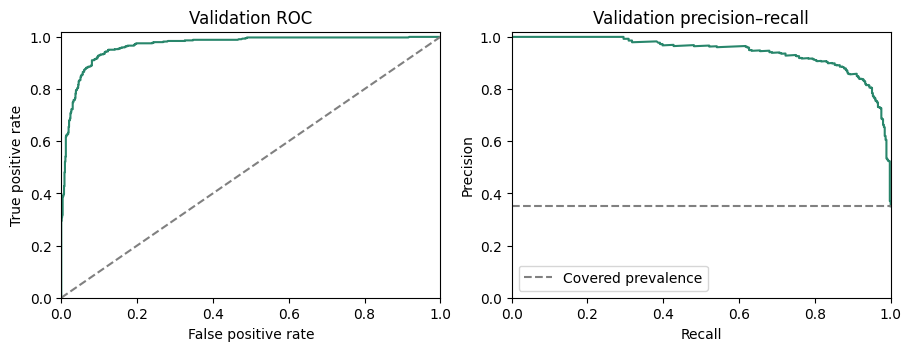

Q1 hashes unchanged; scores, coverage, validation metrics and provenance saved to results/q8/.


In [4]:
report = q8_baseline.run_baseline()

[Scores without labels](results/q8/pilot_scores.csv) · [All matching annotations](results/q8/matched_annotations.csv) · [Coverage](results/q8/coverage.csv) · [Metrics](results/q8/validation_metrics.json) · [Evaluation with ClinVar labels](results/q8/pilot_evaluation.csv)

[Benchmark protocol](results/q8/baseline_protocol.json) · [Benchmark provenance and checks](results/q8/baseline_provenance.json) · [Survey provenance](results/q8/provenance.json) · [Survey comparison](results/q8/tool_comparison.csv)

Generated files and the downloaded archive remain outside Git. The notebook and Python modules reproduce them.

## Conclusion

In [5]:
q8_baseline.show_conclusion(report)

**AlphaMissense is the selected reference predictor; ClinVar remains the ground truth.** It covers **1,276/1,342 validation variants** (95.1%); 66 remain unscored. AUROC **0.967** (95% CI 0.958–0.976); average precision **0.943** (95% CI 0.922–0.960).

Intervals resample Q1 components and describe the covered development cohort. AlphaMissense uses ClinVar calibration, whose exact overlap remains unresolved. These results do not establish clinical validity, performance on missing variants, or superiority to other tools. No Q2 model was retrained or compared against archived broad-SNV results.